In [ ]:
# Analysis of Titanic – Machine Learning from Disaster

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use("default")

In [ ]:
df = pd.read_csv("titanic_train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.shape

(891, 12)

In [ ]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df['Survived'] = df['Survived'].astype('category')

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
#Count of survival or not
df['Survived'].value_counts()

,count
Survived,
0,549
1,342


In [ ]:
#Percentage form
df['Survived'].value_counts(normalize=True) * 100

,proportion
Survived,
0,61.616162
1,38.383838


In [ ]:
#dropping cabin because more missing values
df = df.drop(columns=['Cabin'])

In [ ]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [ ]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
#Univariate Analysis

df = df.replace([np.inf, -np.inf], np.nan)

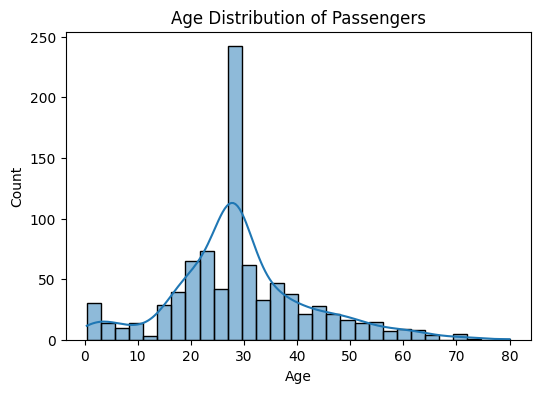

In [ ]:

plt.figure(figsize=(6,4))
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

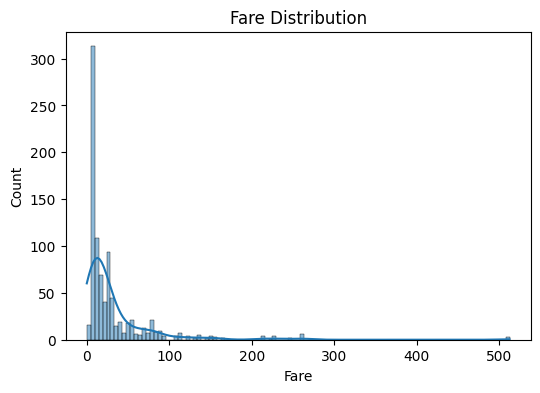

In [ ]:
#Distribution of fare shows price according to poor and rich people
plt.figure(figsize=(6,4))
sns.histplot(df['Fare'], kde=True)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Count")
plt.show()

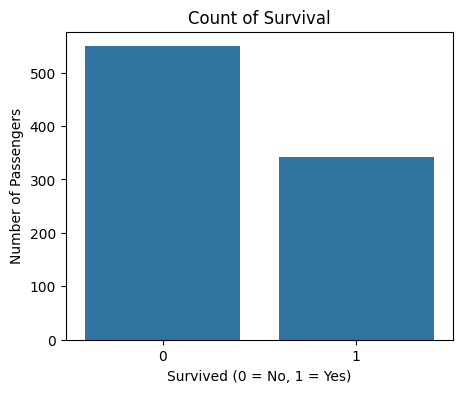

In [ ]:
#Count of Survival (0 vs 1)

plt.figure(figsize=(5,4))
sns.countplot(x='Survived', data=df)
plt.title("Count of Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()

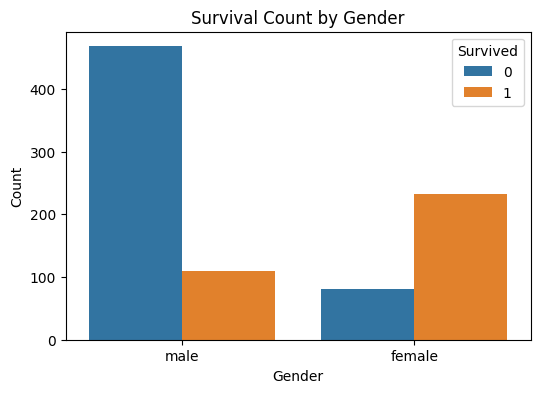

In [ ]:
#Survival by Gender
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()


What this plot shows ?

gender on x-axis

different colors = survived vs not

height of bars = number of passengers

Why it is important ?

1. Titanic survival is strongly related to gender

2. helps see “women and children first” effect

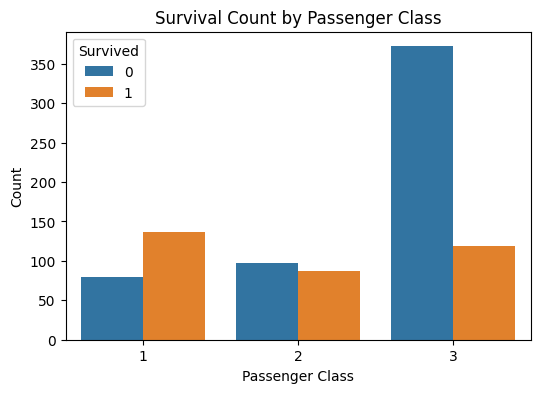

In [ ]:
#Survival by Pclass
plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Survival Count by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.show()

What it shows ?

1st / 2nd / 3rd class vs survival

Why important ?

higher class had better cabins and lifeboat access

strong economic inequality insight

In [ ]:
#Survival by Age Group

df['Age_group'] = pd.cut(df['Age'],
                         bins=[0, 12, 18, 30, 50, 80],
                         labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])

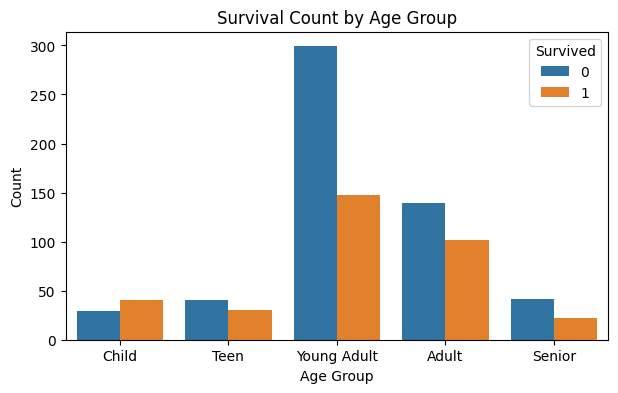

In [ ]:

plt.figure(figsize=(7,4))
sns.countplot(x='Age_group', hue='Survived', data=df)
plt.title("Survival Count by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()

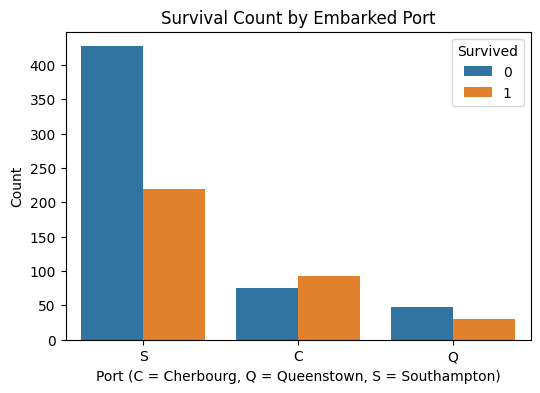

In [ ]:
#Survival by Embarkation Port
plt.figure(figsize=(6,4))
sns.countplot(x='Embarked', hue='Survived', data=df)
plt.title("Survival Count by Embarked Port")
plt.xlabel("Port (C = Cherbourg, Q = Queenstown, S = Southampton)")
plt.ylabel("Count")
plt.show()

Why important ?

passengers from different ports had different:

1. socio-economic background

2. travel purpose

3. affects survival indirectly

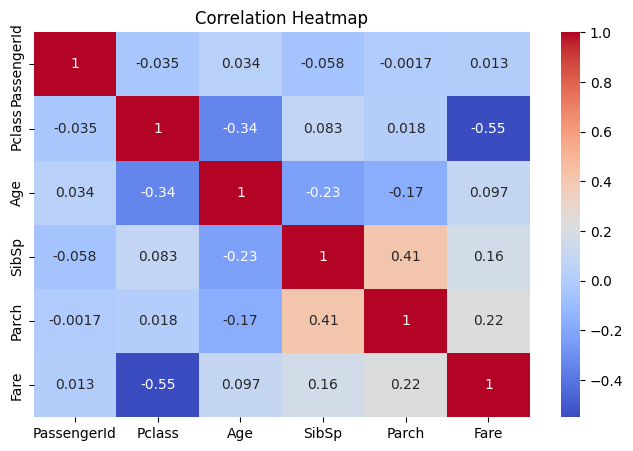

In [ ]:
#Correlation heatmap
numeric_df = df.select_dtypes(include='number')
plt.figure(figsize=(8,5))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


Final insights

Key Insights from Titanic EDA

1. Majority of passengers did not survive

2. Females had a significantly higher survival rate

3. 1st class passengers survived more than 2nd & 3rd class

4. Children had better survival chances than adults

5. Higher fare is associated with higher survival (wealth effect)

6. Passengers embarking from Cherbourg had better survival chances